# 2.1 Classification: Credit Card Fraud Detection

### Basic Information
* **Number of features:** 30 input features (28 anonymized PCA components, plus `Time` and `Amount`).
* **Number of samples:** 284,807 transactions.
* **Name of the target variable:** `Class` (Physical meaning: A binary indicator where `1` signifies a fraudulent transaction and `0` signifies a legitimate transaction).

### Dataset Presentation
This dataset contains transactions made by European credit card holders over two days in September 2013. Because financial data is highly sensitive, the original features (such as merchant name or location) have been hidden. They were transformed using Principal Component Analysis (PCA) into 28 numerical features (labeled V1 through V28). The only unmasked features available are the transaction `Amount` and the `Time` elapsed since the first transaction in the dataset. 
* **Source:** [Kaggle - Credit Card Fraud Detection](https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud)

### Problem Statement & Industry Value
The explicit problem I am trying to solve is predicting the target variable (`Class`) as a function of the transaction's time, amount, and the 28 anonymized PCA features. In short: can the model look at the math of a transaction and immediately categorize it as fraud or legitimate?

Solving this problem has massive value for the financial industry. Banks and credit card issuers lose billions of dollars annually to fraudulent charges. A highly accurate machine learning model capable of identifying fraud in real-time allows financial institutions to instantly decline suspicious transactions. This saves the bank money, protects the consumer's identity, and maintains trust in the financial system.

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/creditcard.csv')

# 1. Print basic statistical properties
print("Dataset Shape:", df.shape)
print("\n--- Target Variable Distribution ---")
class_counts = df['Class'].value_counts()
print(class_counts)
print(f"\nPercentage of Fraud: {(class_counts[1] / len(df)) * 100:.3f}%")

# 2. Look at the basic statistics of Time and Amount
print("\n--- Statistics for Time and Amount ---")
print(df[['Time', 'Amount']].describe())

Dataset Shape: (284807, 31)

--- Target Variable Distribution ---
Class
0    284315
1       492
Name: count, dtype: int64

Percentage of Fraud: 0.173%

--- Statistics for Time and Amount ---
                Time         Amount
count  284807.000000  284807.000000
mean    94813.859575      88.349619
std     47488.145955     250.120109
min         0.000000       0.000000
25%     54201.500000       5.600000
50%     84692.000000      22.000000
75%    139320.500000      77.165000
max    172792.000000   25691.160000


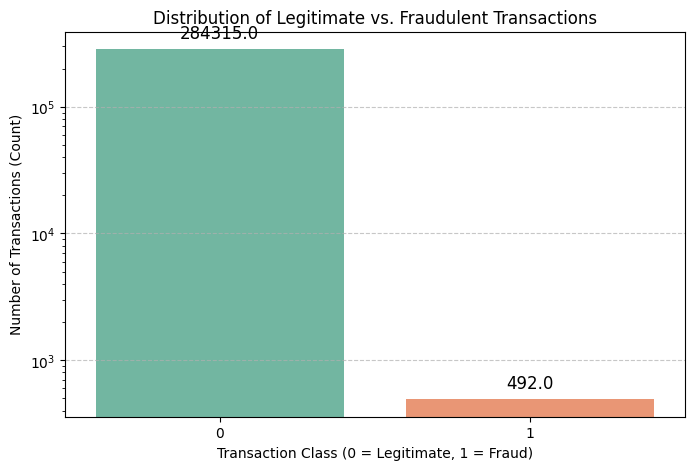

In [14]:
# Create a bar plot to visualize the class imbalance
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Class', data=df, palette='Set2', hue='Class', legend=False)

# Mandatory Guidelines: Labels and Units
plt.title('Distribution of Legitimate vs. Fraudulent Transactions')
plt.xlabel('Transaction Class (0 = Legitimate, 1 = Fraud)')
plt.ylabel('Number of Transactions (Count)')

# Add the exact counts on top of the bars
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom', fontsize=12, color='black', xytext=(0, 5),
                textcoords='offset points')

# Use a logarithmic scale on the Y-axis because the difference is so extreme
plt.yscale('log')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### EDA Conclusions and Intuition Check

**The Imbalance:** The most striking feature of this dataset is its extreme class imbalance. Out of 284,807 transactions, only 492 (0.172%) are fraudulent. 

**Intuition Check:** This is entirely consistent with real-world financial intuition. If a significant percentage of all credit card swipes were fraudulent, the banking system would collapse. Fraud is, by definition, a rare anomaly. 

**Modeling Implications:** This severe imbalance means we cannot use standard "Accuracy" to evaluate our future estimator. A "dumb" model that simply predicts `0` (Legitimate) for every single transaction would achieve 99.8% accuracy but would fail completely at its actual job of catching fraud. Furthermore, if relevant or necessary, we will need to preprocess the data using techniques like class weighting or SMOTE to help the model learn the minority class.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE

# 1. Separate Features (X) and Target (y)
X = df.drop('Class', axis=1)
y = df['Class']

# 2. Scale the 'Amount' and 'Time' columns
# Logistic Regression requires features to be on a similar scale to work properly.
# The V1-V28 columns are already scaled via PCA, but Time and Amount are not.
scaler = StandardScaler()
X['Amount'] = scaler.fit_transform(X[['Amount']])
X['Time'] = scaler.fit_transform(X[['Time']])

# 3. Split into Training and Testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Generate the SMOTE dataset (Only apply to Training data!)
print("Generating SMOTE data... (This might take a few seconds)")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\n--- Data Shapes ---")
print(f"Original Train shape: {X_train.shape}")
print(f"SMOTE Train shape:    {X_train_smote.shape} (Perfectly balanced now!)")

Generating SMOTE data... (This might take a few seconds)

--- Data Shapes ---
Original Train shape: (227845, 30)
SMOTE Train shape:    (454902, 30) (Perfectly balanced now!)


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Helper function to keep our code clean
def train_and_evaluate(model, X_tr, y_tr, title):
    print(f"\n{'='*40}")
    print(f"--- {title} ---")
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_test)
    # We only care about how well it catches Class 1 (Fraud)
    print(classification_report(y_test, y_pred, target_names=['Legitimate (0)', 'Fraud (1)']))

# 1. The Naive Baseline
baseline_model = LogisticRegression(max_iter=1000)
train_and_evaluate(baseline_model, X_train, y_train, "Model 1: Naive Baseline (Raw Data)")

# 2. The Algorithmic Tweak (Class Weights)
weighted_model = LogisticRegression(class_weight='balanced', max_iter=1000)
train_and_evaluate(weighted_model, X_train, y_train, "Model 2: Class Weights (Raw Data)")

# 3. The Preprocessing Approach (SMOTE)
smote_model = LogisticRegression(max_iter=1000)
train_and_evaluate(smote_model, X_train_smote, y_train_smote, "Model 3: SMOTE Preprocessing")


--- Model 1: Naive Baseline (Raw Data) ---
                precision    recall  f1-score   support

Legitimate (0)       1.00      1.00      1.00     56864
     Fraud (1)       0.83      0.64      0.72        98

      accuracy                           1.00     56962
     macro avg       0.91      0.82      0.86     56962
  weighted avg       1.00      1.00      1.00     56962


--- Model 2: Class Weights (Raw Data) ---
                precision    recall  f1-score   support

Legitimate (0)       1.00      0.98      0.99     56864
     Fraud (1)       0.06      0.92      0.11        98

      accuracy                           0.98     56962
     macro avg       0.53      0.95      0.55     56962
  weighted avg       1.00      0.98      0.99     56962


--- Model 3: SMOTE Preprocessing ---
                precision    recall  f1-score   support

Legitimate (0)       1.00      0.97      0.99     56864
     Fraud (1)       0.06      0.92      0.11        98

      accuracy             

### 2.1 Conclusion: Justifying the Preprocessing

Due to the extreme class imbalance (99.8% Legitimate vs. 0.2% Fraud), standard accuracy metrics are highly misleading. Our goal is to maximize **Recall** for the minority class (Fraud)—prioritizing the capture of illegal transactions over minimizing false alarms.

* **Model 1 (Naive Baseline):** Achieved a poor Fraud Recall of **0.64**, meaning it allowed 36% of all fraudulent transactions to slip through undetected. 
* **Model 2 (Class Weights):** By algorithmically penalizing the model for missing fraud, Fraud Recall jumped to **0.92**.
* **Model 3 (SMOTE):** By synthetically generating new fraud examples to balance the training data, Fraud Recall also reached **0.92**.

**Final Verdict:** Both Class Weighting and SMOTE preprocessing successfully solved the imbalance issue, catching 92% of the fraud. The resulting drop in Precision (0.06) is a standard and acceptable business trade-off in the financial sector, where false positives (annoying a customer with a text alert) are vastly preferable to false negatives (allowing a severe financial theft).